<a href="https://cognitiveclass.ai"><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0101EN-SkillsNetwork/images/IDSN-logo.png" width="400"> 

# Keras ile Transformers

Tahmini süre **45** dakika

Bu laboratuvarda, Keras kütüphanesini kullanarak çeviri için öz-dikkat (self-attention) özelliğine sahip bir dizi-dizi mimarisi temelinde bir dönüştürücü (transformer) modelini nasıl oluşturacağımızı öğreneceğiz. Modeli örnek bir veri kümesi kullanarak eğitecek ve ardından bu modeli İngilizce’den İspanyolca’ya çeviri yapmak için kullanacağız.


# Bu Çalışma Kitabının Hedefleri    
* Keras kütüphanesini kullanarak Transformer modeli oluşturma
* Verilen veri kümesini kullanarak Transformer modelini eğitme
* Eğitilmiş Transformer modelini çeviri yapmak için kullanma


İçindekiler


<div class="alert alert-block alert-info" style="margin-top: 20px">

<font size = 4>
1. <a href="#Import-Keras-and-Packages">Keras ve Paketleri İçe Aktarma

2. <a href="#Step-1:-Data-Preparation">Adım 1: Veri Hazırlama

3. <a href="#Step-2:-Self-Attention-Layer">Adım 2: Öz Dikkat Katmanı

4. <a href="#Step-3:-Model-Architecture">Adım 3: Model Mimarisi

5. <a href="#Step-4:-Training-the-Model">Adım 4: Modelin Eğitimi

6. <a href="#Step-5:-Plotting-the-training-loss">Adım 5: Eğitim kaybının grafiğinin çizilmesi</font>


</font>


## Keras ve Paketleri İçe Aktar


Öncelikle, bir sinir ağı oluşturmak için ihtiyaç duyacağımız Keras kütüphanelerini ve paketleri içe aktaralım.


Aşağıdaki gerekli kütüphaneler, Skills Network Labs ortamında önceden yüklenmiş değildir. Bunları yüklemek için aşağıdaki hücreyi çalıştırmanız gerekecektir:


In [1]:
!pip install tensorflow_cpu==2.17.1
!pip install matplotlib==3.9.2

print("==== All required libraries are installed =====")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.4/221.4 MB 27.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 57.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 53.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow_cpu
    Found existing installation: tensorflow_cpu 2.18.0
    Uninstalling tensorflow_cpu-2.18.0:
      Successfully uninstalled tensorflow_cpu-2.18.0
==== All required libraries are installed =====


#### TensorFlow uyarı mesajlarını gizleme
TensorFlow'da CPU mimarisinin kullanılması nedeniyle ortaya çıkan uyarı mesajlarını gizlemek için aşağıdaki kodu kullanıyoruz.

GPU mimarisini kullanıyorsanız, bu satırları **yorum satırına dönüştürmek** isteyebilirsiniz


In [33]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

##### Keras'ı kullanmak için TensorFlow gibi bir arka uç çerçeve de yüklemeniz gerekecektir.

TensorFlow 2.16 veya üstü bir sürümü yüklediğinizde, Keras varsayılan olarak kurulacaktır.

Daha küçük veri kümeleriyle çalıştığımız için TensorFlow'un CPU sürümünü kullanıyoruz.
Daha büyük veri kümelerinin işlenmesini hızlandırmak için bilgisayarınıza TensorFlow'un GPU sürümünü yükleyebilirsiniz.


### Import the necessary libraries


In [34]:
import numpy as np
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import backend as K
from keras.layers import Layer
import warnings
warnings.simplefilter('ignore', FutureWarning)

# Adım 1: Veri Hazırlama
Çeviri eğitimi için cümleleri ve metni tanımlayarak başlıyoruz
Cümle Çiftleri: İngilizce-İspanyolca cümle çiftlerinden oluşan küçük bir veri kümesini tanımlar.
Hedef Diziler:
Çözücünün çeviriye ne zaman başlayıp ne zaman bitireceğini öğrenmesi için her hedef cümlenin başına “startseq” eklenir ve sonuna “endseq” eklenir.


In [35]:
# Sample parallel sentences (English -> Spanish)
input_texts = [
    "Hello.", "How are you?", "I am learning machine translation.", "What is your name?", "I love programming."
]
target_texts = [
    "Hola.", "¿Cómo estás?", "Estoy aprendiendo traducción automática.", "¿Cuál es tu nombre?", "Me encanta programar."
]

target_texts = ["startseq " + x + " endseq" for x in target_texts]

## Ardından, cümlelerdeki metni tokenlere dönüştürüp bir kelime haznesi oluşturuyoruz
Tokenleştirme: Kelimeleri sayısal dizilere dönüştürmek için Tokenizer kullanılır.


In [36]:
input_tokenizer = Tokenizer()  # Girdi metinleri için tokenizer oluştur
input_tokenizer.fit_on_texts(input_texts)  # Girdi metinlerindeki kelimelere indeks ataması yap
input_sequences = input_tokenizer.texts_to_sequences(input_texts)  # Metinleri sayısal dizilere çevir

output_tokenizer = Tokenizer()  # Çıktı metinleri için tokenizer oluştur
output_tokenizer.fit_on_texts(target_texts)  # Çıktı metinlerindeki kelimelere indeks ataması yap
output_sequences = output_tokenizer.texts_to_sequences(target_texts)  # Çıktı metinlerini sayısal dizilere çevir

input_vocab_size = len(input_tokenizer.word_index) + 1  # Girdi kelime sayısı (0 padding için ayrıldı)
output_vocab_size = len(output_tokenizer.word_index) + 1  # Çıktı kelime sayısı (0 padding için ayrıldı)

### Şimdi ilgili cümleleri doldurun
Doldurma: Tüm dizilerin aynı uzunlukta olmasını sağlar.


In [37]:
# Padding işlemi: tüm dizileri aynı uzunluğa getiriyoruz

max_input_length = max([len(seq) for seq in input_sequences])  # Girdi dizilerindeki en uzun sequence uzunluğunu bul
max_output_length = max([len(seq) for seq in output_sequences])  # Çıktı dizilerindeki en uzun sequence uzunluğunu bul

input_sequences = pad_sequences(input_sequences, maxlen=max_input_length, padding='post')  
# Girdi dizilerini max_input_length uzunluğuna getir, eksik kısımları sonuna 0 ekleyerek tamamla

output_sequences = pad_sequences(output_sequences, maxlen=max_output_length, padding='post')  
# Çıktı dizilerini max_output_length uzunluğuna getir, eksik kısımları sonuna 0 ekleyerek tamamla

In [38]:
# Hedef veriyi eğitim için hazırla

decoder_input_data = output_sequences[:, :-1] # Decoder'a giriş olarak verilecek: tüm çıktı dizileri, son token hariç

decoder_output_data = output_sequences[:, 1:]  
# Decoder'ın tahmin etmesini istediğimiz veri: tüm çıktı dizileri, ilk token hariç (yani kaydırılmış çıktı)

# One-hot formatına çevir
decoder_output_data = np.array([np.eye(output_vocab_size)[seq] for seq in decoder_output_data])  
# Her token'ı output_vocab_size uzunluğunda bir vektöre çeviriyoruz
# Örn: token 3 → [0,0,0,1,0,...,0]

# Adım 2: Öz-Dikkat Katmanı
Öz-dikkat, bir modelin her bir kelimeyi işlerken **giriş dizisinin ilgili kısımlarına odaklanmasını** sağlayan bir mekanizmadır. Bu özellikle şu alanlarda yararlıdır:
1) Makine Çevirisi (ör. kelimeleri doğru şekilde eşleştirme)
2) Metin Özetleme
3) Konuşma Tanıma
4) Görüntü İşleme (Vision Transformers)
Bu uygulamada, öz-dikkat, metin tabanlı diziden diziye modelleme için kullanılır.


Öz-dikkat, her konum için tüm kelimelerin ağırlıklı temsilini hesaplayarak belirli bir girdi dizisi için çalışır. Bunu üç temel bileşen kullanarak yapar:

1. Sorgu **(Q)**, Anahtar **(K)** ve Değer **(V)** Matrisleri
Bir dizideki her kelime (token) için:

Sorgu (Q): Bu kelimenin aradığı şey.
Anahtar (K): Bu kelimenin temsil ettiği şey.
Değer (V): Kelimedeki gerçek bilgi.

2. **Dikkat Puanlarını** Hesaplama
Ardından, nokta çarpımı dikkatini kullanarak **her sorgu ve anahtar arasındaki benzerliği hesaplarız**:
Dizideki her kelime, bu puanlara göre diğer tüm kelimelere dikkat eder.

3. **Ölçeklendirme ve Softmax** Uygulama
Nokta çarpımı değerleri büyük olabileceğinden, bunları ölçeklendiririz. 
Ardından, softmax uygulayarak puanları dikkat ağırlıklarına dönüştürürüz:


In [39]:
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)
        # Öz-dikkat (self-attention) katmanını başlatıyoruz

    def build(self, input_shape):
        # input_shape bir liste: [query, key, value şekilleri]
        feature_dim = input_shape[0][-1]  # Özellik boyutu (embedding boyutu)

        # Query ağırlık matrisi, öğrenilebilir
        self.Wq = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wq'
        )

        # Key ağırlık matrisi, öğrenilebilir
        self.Wk = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wk'
        )

        # Value ağırlık matrisi, öğrenilebilir
        self.Wv = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wv'
        )

        super(SelfAttention, self).build(input_shape)
        # Katmanın build metodunu tamamla

    def call(self, inputs):
        # Beklenen input: [query, key, value] listesi
        q, k, v = inputs  # Inputları ayır: q, k, v

        q = K.dot(q, self.Wq)  # Query'yi lineer dönüşümden geçir
        k = K.dot(k, self.Wk)  # Key'i lineer dönüşümden geçir
        v = K.dot(v, self.Wv)  # Value'yu lineer dönüşümden geçir

        # Ölçeklenmiş nokta çarpımı dikkat
        scores = K.batch_dot(q, k, axes=[2, 2])  # Q ve K arasındaki nokta çarpımı → dikkat skorları
        dk = K.cast(K.shape(k)[-1], dtype=K.floatx())  # Key boyutunu float olarak al
        scores = scores / K.sqrt(dk)  # Skorları ölçeklendir

        attention_weights = K.softmax(scores, axis=-1)  # Softmax ile dikkat ağırlıklarını elde et
        output = K.batch_dot(attention_weights, v)  # Dikkat ağırlıkları ile Value'ların ağırlıklı toplamını al

        return output  # Bağlamsallaştırılmış (context) vektörü döndür

# Adım 3: Model Mimarisi
Model, bir Kodlayıcı-Çözücü yapısını takip eder:

### Kodlayıcı:
1) Giriş cümlelerini alır (dolgulanmış ve tokenize edilmiş).
2) Bir Gömme katmanı (kelime temsilleri) + LSTM (dizileri işlemek için) kullanır.
    1. LSTM'ler, **değişken uzunluktaki girdi cümlelerini işlemek** ve anlamlı çeviriler üretmek için kullanılır.
4) Bağlam vektörleri (gizli ve hücre durumları) çıkarır.

### Dikkat Katmanı
1) Hem kodlayıcı hem de kod çözücü çıktısına uygulanır.
2) Kod çözücünün çeviri sırasında ilgili kelimelere odaklanmasına yardımcı olur.

### Dekoder
1) Hedef dizileri alır (bir adım ileriye kaydırılmış).
2) İlk durumlar olarak kodlayıcı durumlarını içeren bir LSTM kullanır.
3) Daha iyi öğrenme için öz-dikkat uygular.
4) Bir sonraki kelimeyi tahmin etmek için Yoğun katman (Softmax) kullanır.


In [40]:
from tensorflow.keras.layers import AdditiveAttention, Concatenate, Dense, Embedding, Input, LSTM
from tensorflow.keras.models import Model

# ---------- ENCODER ----------
encoder_inputs = Input(shape=(max_input_length,))  
# Encoder giriş katmanı, boyutu max_input_length

encoder_embedding = Embedding(input_vocab_size, 256)(encoder_inputs)  
# Encoder embedding katmanı: kelimeleri 256 boyutlu vektörlere çevir

encoder_lstm = LSTM(256, return_sequences=True, return_state=True)  
# Encoder LSTM katmanı, tüm zaman adımlarının çıktısını döndür ve son durumu sakla

encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)  
# Encoder çıktısı ve son gizli/durum hücrelerini al

encoder_states = [state_h, state_c]  
# Decoder için başlangıç durumu olarak sakla

# ---------- DECODER ----------
decoder_inputs = Input(shape=(max_output_length - 1,))  
# Decoder giriş katmanı, boyutu max_output_length-1 (teacher forcing için kaydırılmış)

decoder_embedding = Embedding(output_vocab_size, 256)(decoder_inputs)  
# Decoder embedding katmanı: kelimeleri 256 boyutlu vektörlere çevir

decoder_lstm = LSTM(256, return_sequences=True, return_state=True)  
# Decoder LSTM katmanı, tüm zaman adımlarının çıktısını döndür ve son durumu sakla

decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)  
# Decoder LSTM'yi çalıştır, başlangıç durumu encoder_states

# ---------- ATTENTION ----------
self_attention = SelfAttention()  
# Self-attention katmanı oluştur

attention_output = self_attention(
    [decoder_outputs, encoder_outputs, encoder_outputs]
)  
# Decoder çıktıları, encoder çıktıları üzerinde dikkat uygula
# (query=decoder, key=value=encoder_outputs)

# ---------- DECODER + ATTENTION BİRLEŞTİRME ----------
decoder_concat = Concatenate(axis=-1)([decoder_outputs, attention_output])  
# Decoder çıktıları ile dikkat bağlamını birleştir

# ---------- FINAL DENSE LAYER ----------
decoder_dense = Dense(output_vocab_size, activation='softmax')  
# Çıktıyı kelime olasılıkları hâline getiren dense katman

decoder_outputs = decoder_dense(decoder_concat)  
# Dense katmandan geçir, modelin son çıktısı

# ---------- MODEL TANIMI ----------
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)  
# Encoder ve decoder girişlerini ve decoder çıktısını kullanarak modeli oluştur

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  
# Modeli derle: optimizer adam, loss categorical_crossentropy (one-hot çıktılar için), accuracy metriği

# ---------- MODEL ÖZETİ ----------
model.summary()  
# Modelin katmanlarını ve parametre sayılarını göster

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_31      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_30        │ (None, 5, 256)    │      4,096 │ input_layer_30[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_31        │ (None, 5, 256)    │      4,352 │ input_layer_31[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_30 (LSTM)      │ [(None, 5, 256),  │    525,312 │ embedding_30[0][… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_31 (LSTM)      │ [(None, 5, 256),  │    525,312 │ embedding_31[0][… │
│                     │ (None, 256),      │            │ lstm_30[0][1],    │
│                     │ (None, 256)]      │            │ lstm_30[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_15   │ (None, 5, 256)    │    196,608 │ lstm_31[0][0],    │
│ (SelfAttention)     │                   │            │ lstm_30[0][0],    │
│                     │                   │            │ lstm_30[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_15      │ (None, 5, 512)    │          0 │ lstm_31[0][0],    │
│ (Concatenate)       │                   │            │ self_attention_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 5, 17)     │      8,721 │ concatenate_15[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,264,401 (4.82 MB)

 Trainable params: 1,264,401 (4.82 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Adım: Modelin Eğitilmesi
Çıktı kelimeleri tek-sıcak kodlamaya tabi tutulduğu için kayıp fonksiyonu olarak categorical_crossentropy kullanılır.
Adam optimizörü kullanılarak 100 epok boyunca eğitilir.


In [41]:
# Step 6: Train the Model
history_glorot_adam = model.fit([input_sequences, decoder_input_data], decoder_output_data, epochs=100, batch_size=16)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.1200 - loss: 2.8309
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.4400 - loss: 2.7969
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.3600 - loss: 2.7607
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.3200 - loss: 2.7176
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.3200 - loss: 2.6633
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.3200 - loss: 2.5923
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.2800 - loss: 2.4992
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.2800 - loss: 2.3799
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.2800 - loss: 2.2400
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.2800 - loss: 2.1147
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.2800 - loss: 2.0632
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.

# Step 5: Plotting the training loss


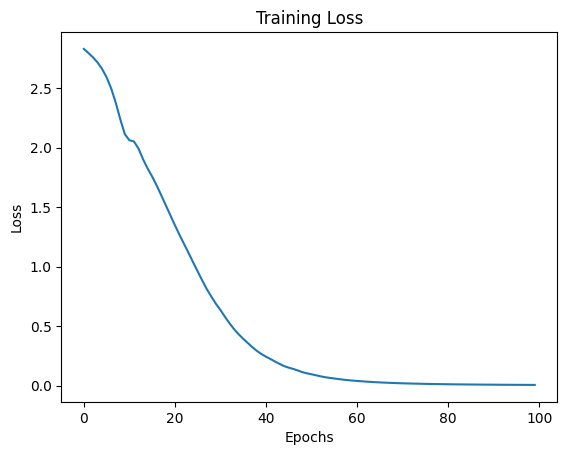

In [42]:
# Plotting training loss
import matplotlib.pyplot as plt
plt.plot(history_glorot_adam.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Awesome, now you have succesfully trained a transformers model.
### Now let's try some practice excercises


## Practice excercise 1


Bu alıştırmada, modeli “glorot_uniform” yerine “he_uniform” başlatıcısını kullanarak eğitelim. Ardından, matplotlib ile grafiklerini çizerek ‘glorot_uniform’ ve “he_uniform” başlatıcılarını kullanan modellerin eğitim kayıplarını karşılaştıralım.


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0800 - loss: 2.8350
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4000 - loss: 2.7935
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.3200 - loss: 2.7497
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.3200 - loss: 2.6988
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.3200 - loss: 2.6359
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.3200 - loss: 2.5560
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.2800 - loss: 2.4546
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.2800 - loss: 2.3318
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.2800 - loss: 2.2062
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.2800 - loss: 2.1305
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.2800 - loss: 2.1152
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.

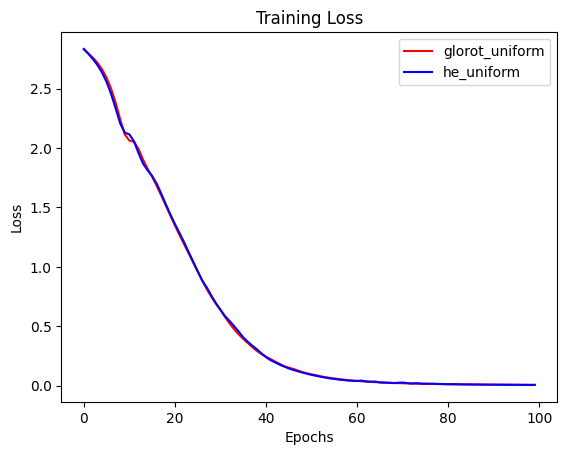

In [43]:
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape is a list: [q_shape, k_shape, v_shape]
        feature_dim = input_shape[0][-1]

        self.Wq = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='he_uniform',
            trainable=True,
            name='Wq'
        )

        self.Wk = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='he_uniform',
            trainable=True,
            name='Wk'
        )

        self.Wv = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='he_uniform',
            trainable=True,
            name='Wv'
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, inputs):
        # Expect list: [query, key, value]
        q, k, v = inputs

        q = K.dot(q, self.Wq)
        k = K.dot(k, self.Wk)
        v = K.dot(v, self.Wv)

        # Scaled dot-product attention
        scores = K.batch_dot(q, k, axes=[2, 2])
        dk = K.cast(K.shape(k)[-1], dtype=K.floatx())
        scores = scores / K.sqrt(dk)

        attention_weights = K.softmax(scores, axis=-1)
        output = K.batch_dot(attention_weights, v)

        return output


from tensorflow.keras.layers import AdditiveAttention, Concatenate, Dense, Embedding, Input, LSTM
from tensorflow.keras.models import Model
 
# Encoder
encoder_inputs = Input(shape=(max_input_length,))
encoder_embedding = Embedding(input_vocab_size, 256)(encoder_inputs)
encoder_lstm = LSTM(256, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]
 
# Decoder
decoder_inputs = Input(shape=(max_output_length - 1,))
decoder_embedding = Embedding(output_vocab_size, 256)(decoder_inputs)
decoder_lstm = LSTM(256, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
 
# Attention: decoder attends to encoder outputs
self_attention = SelfAttention()
attention_output = self_attention(
    [decoder_outputs, encoder_outputs, encoder_outputs]
)

 
# Combine decoder outputs with attention context
decoder_concat = Concatenate(axis=-1)([decoder_outputs, attention_output])
 
# Final Dense layer
decoder_dense = Dense(output_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_concat)
 
# Full Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
# Summary
#Step 6: Train the Model
history_he = model.fit([input_sequences, decoder_input_data], decoder_output_data, epochs=100, batch_size=16)

#Plotting training losses for glorot_uniform and he_uniform inititalizers
import matplotlib.pyplot as plt
plt.plot(history_glorot_adam.history['loss'], label="glorot_uniform", color='red')
plt.plot(history_he.history['loss'], label="he_uniform", color='blue')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Double-click <b>here</b> for the solution.

<!-- Your answer is below:


#Define the Self-Attention Layer
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape is a list: [q_shape, k_shape, v_shape]
        feature_dim = input_shape[0][-1]

        self.Wq = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='he_uniform',
            trainable=True,
            name='Wq'
        )

        self.Wk = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='he_uniform',
            trainable=True,
            name='Wk'
        )

        self.Wv = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='he_uniform',
            trainable=True,
            name='Wv'
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, inputs):
        # Expect list: [query, key, value]
        q, k, v = inputs

        q = K.dot(q, self.Wq)
        k = K.dot(k, self.Wk)
        v = K.dot(v, self.Wv)

        # Scaled dot-product attention
        scores = K.batch_dot(q, k, axes=[2, 2])
        dk = K.cast(K.shape(k)[-1], dtype=K.floatx())
        scores = scores / K.sqrt(dk)

        attention_weights = K.softmax(scores, axis=-1)
        output = K.batch_dot(attention_weights, v)

        return output


from tensorflow.keras.layers import AdditiveAttention, Concatenate, Dense, Embedding, Input, LSTM
from tensorflow.keras.models import Model
 
# Encoder
encoder_inputs = Input(shape=(max_input_length,))
encoder_embedding = Embedding(input_vocab_size, 256)(encoder_inputs)
encoder_lstm = LSTM(256, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]
 
# Decoder
decoder_inputs = Input(shape=(max_output_length - 1,))
decoder_embedding = Embedding(output_vocab_size, 256)(decoder_inputs)
decoder_lstm = LSTM(256, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
 
# Attention: decoder attends to encoder outputs
self_attention = SelfAttention()
attention_output = self_attention(
    [decoder_outputs, encoder_outputs, encoder_outputs]
)

 
# Combine decoder outputs with attention context
decoder_concat = Concatenate(axis=-1)([decoder_outputs, attention_output])
 
# Final Dense layer
decoder_dense = Dense(output_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_concat)
 
# Full Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
# Summary
#Step 6: Train the Model
history_he = model.fit([input_sequences, decoder_input_data], decoder_output_data, epochs=100, batch_size=16)

#Plotting training losses for glorot_uniform and he_uniform inititalizers
import matplotlib.pyplot as plt
plt.plot(history_glorot_adam.history['loss'], label="glorot_uniform", color='red')
plt.plot(history_he.history['loss'], label="he_uniform", color='blue')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


-->


## Practice excercise 2


Bu alıştırmada, adam yerine uyarlanabilir gradyan optimizörünü kullanmayı deneyin. Ardından, sonuçları grafik haline getirin ve adam ile uyarlanabilir gradyan optimizörleri arasındaki sonuçları karşılaştırın


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.0061
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 0.0061
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 1.

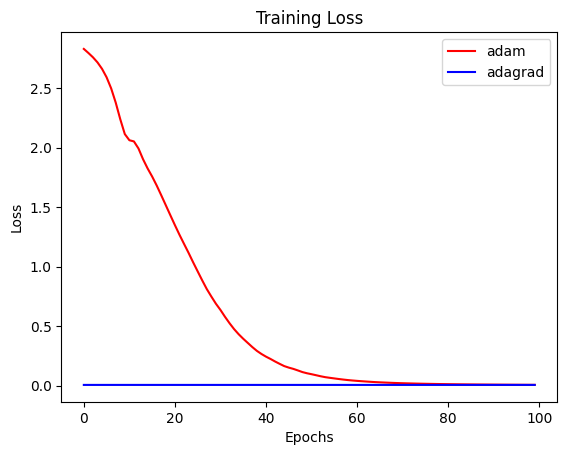

In [44]:
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adagrad', loss='categorical_crossentropy', metrics=['accuracy'])


#Step 6: Train the Model
history_adagrad = model.fit([input_sequences, decoder_input_data], decoder_output_data, epochs=100, batch_size=16)

#Plotting training losses for glorot_uniform and he_uniform inititalizers
import matplotlib.pyplot as plt
plt.plot(history_glorot_adam.history['loss'], label="adam", color='red')
plt.plot(history_adagrad.history['loss'], label="adagrad", color='blue')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Adam → hızlı ve etkili öğrenmiş

Adagrad → öğrenme başarısız

## Thank you for completing this lab!

This notebook was created by [Aman Aggarwal](https://www.linkedin.com/in/aggarwal-aman/). I hope you found this lab interesting and educational. Feel free to contact me if you have any questions!


Double-click <b>here</b> for the solution.

<!-- Your answer is below:

#Full Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adagrad', loss='categorical_crossentropy', metrics=['accuracy'])


#Step 6: Train the Model
history_adagrad = model.fit([input_sequences, decoder_input_data], decoder_output_data, epochs=100, batch_size=16)

#Plotting training losses for glorot_uniform and he_uniform inititalizers
import matplotlib.pyplot as plt
plt.plot(history_glorot_adam.history['loss'], label="adam", color='red')
plt.plot(history_adagrad.history['loss'], label="adagrad", color='blue')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
-->


<!--
## Change Log

|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2024-11-20  | 1.0  | Aman  |  Created the lab |
<hr>
-->
## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>
